In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

from pathlib import Path
import subprocess

In [2]:
default_params = {
    # Output
    "output": "tCl,pCl,lCl,mPk",
    "modes": "s",
    "ic": "ad",
    "gauge": "synchronous",

    # Background / cosmology
    "h": 0.67810,
    "YHe": "BBN",
    "recombination": "HyRec",
    "reio_parametrization": "reio_camb",
    "z_reio": 7.6711,
    "reionization_exponent": 1.5,
    "reionization_width": 0.5,
    "helium_fullreio_redshift": 3.5,
    "helium_fullreio_width": 0.5,

    "varying_fundamental_constants": "none",
    "T_cmb": 2.7255,

    "omega_b": 0.02238280,
    "N_ur": 3.044,
    "omega_cdm": 0.1201075,
    "Omega_k": 0.0,

    # Dark sector
    "Omega_dcdmdr": 0.0,
    "f_idm": 0.0,
    "stat_f_idr": 0.875,
    "Omega_fld": 0.0,
    "Omega_scf": 0.0,

    # DM / PBH effects
    "DM_annihilation_efficiency": 0.0,
    "DM_decay_fraction": 0.0,
    "DM_decay_Gamma": 0.0,

    "PBH_evaporation_fraction": 0.0,
    "PBH_evaporation_mass": 0.0,
    "PBH_accretion_fraction": 0.0,
    "PBH_accretion_mass": 0.0,
    "PBH_accretion_recipe": "disk_accretion",
    "PBH_accretion_ADAF_delta": 1.e-3,
    "PBH_accretion_eigenvalue": 0.1,

    "f_eff_type": "on_the_spot",
    "chi_type": "CK_2004",

    # Primordial spectrum
    "Pk_ini_type": "analytic_Pk",
    "k_pivot": 0.05,
    "A_s": 2.100549e-09,
    "n_s": 0.9660499,
    "alpha_s": 0.0,

    # Precision
    "l_max_scalars": 4000,
    "P_k_max_h/Mpc": 1.0,
    "z_pk": 0,

    # Lensing
    "lensing": "yes",
    "want_lcmb_full_limber": "yes",

    # Spectral distortions
    "sd_branching_approx": "exact",
    "sd_PCA_size": 2,
    "sd_detector_name": "PIXIE",
    "sd_only_exotic": "no",
    "sd_include_g_distortion": "no",
    "sd_add_y": 0.0,
    "sd_add_mu": 0.0,

    # SZ
    "include_SZ_effect": "no",

    # Output options
    "overwrite_root": "no",
    "headers": "yes",
    "format": "class",
    "write_background": "no",
    "write_thermodynamics": "no",
    "write_primordial": "no",
    "write_exotic_injection": "no",
    "write_distortions": "no",
    "write_parameters": "yes",
    "write_warnings": "no",

    # Verbosity
    "input_verbose": 1,
    "background_verbose": 1,
    "thermodynamics_verbose": 1,
    "perturbations_verbose": 1,
    "transfer_verbose": 1,
    "primordial_verbose": 1,
    "harmonic_verbose": 1,
    "fourier_verbose": 1,
    "lensing_verbose": 1,
    "distortions_verbose": 1,
    "output_verbose": 1,
}

In [34]:
thomson_rescaling_values = [0.9, 0.95, 1.0, 1.05, 1.1]

for tr in thomson_rescaling_values:
    tr_name = f"{tr:g}".replace(".", "p") # e.g. 0.95 -> "0p95"

    ini_path = Path(f"Ad{tr_name}_rescale.ini")
    params = default_params.copy()
    params["root"] = f"../output/Ad{tr_name}_rescale_"
    params["thomson_rescaling"] = tr

    with open(ini_path, "w") as f:
        for key, value in params.items():
            f.write(f"{key} = {value}\n")
    print(f"Wrote {ini_path}")

    result = subprocess.run(
        ["../class", str(ini_path)],
        capture_output=True,
        text=True
    )
    print(result.stdout)
    if result.returncode != 0:
        print("CLASS ERROR:")
        print(result.stderr)
    else:
        print(f"Finished thomson_rescaling = {tr}")

Wrote Ad0p9_rescale.ini
Reading input parameters
 -> matched budget equations by adjusting Omega_Lambda = 0.690026
Running CLASS version v3.4.0
Computing background
 -> age = 13.770598 Gyr
 -> conformal age = 14151.897989 Mpc
 -> N_eff = 3.044 (summed over all species that are non-relativistic at early times) 
 -> radiation/matter equality at z = 3405.751108
    corresponding to conformal time = 112.722902 Mpc
Computing thermodynamics using HyRec 2020
 -> with primordial helium mass fraction Y_He = 0.2453
 -> recombination (maximum of visibility function) at z = 1097.064438
    corresponding to conformal time = 279.066941 Mpc
    with comoving sound horizon = 143.792163 Mpc
    angular diameter distance = 12.633895 Mpc
    sound horizon angle 100*theta_s = 1.036502
    Thomson optical depth crosses one at z_* = 1094.621539
    giving an angle 100*theta_* = 1.038056
 -> baryon drag stops at z = 1067.859326
    corresponding to conformal time = 284.732696 Mpc
    with comoving sound hori

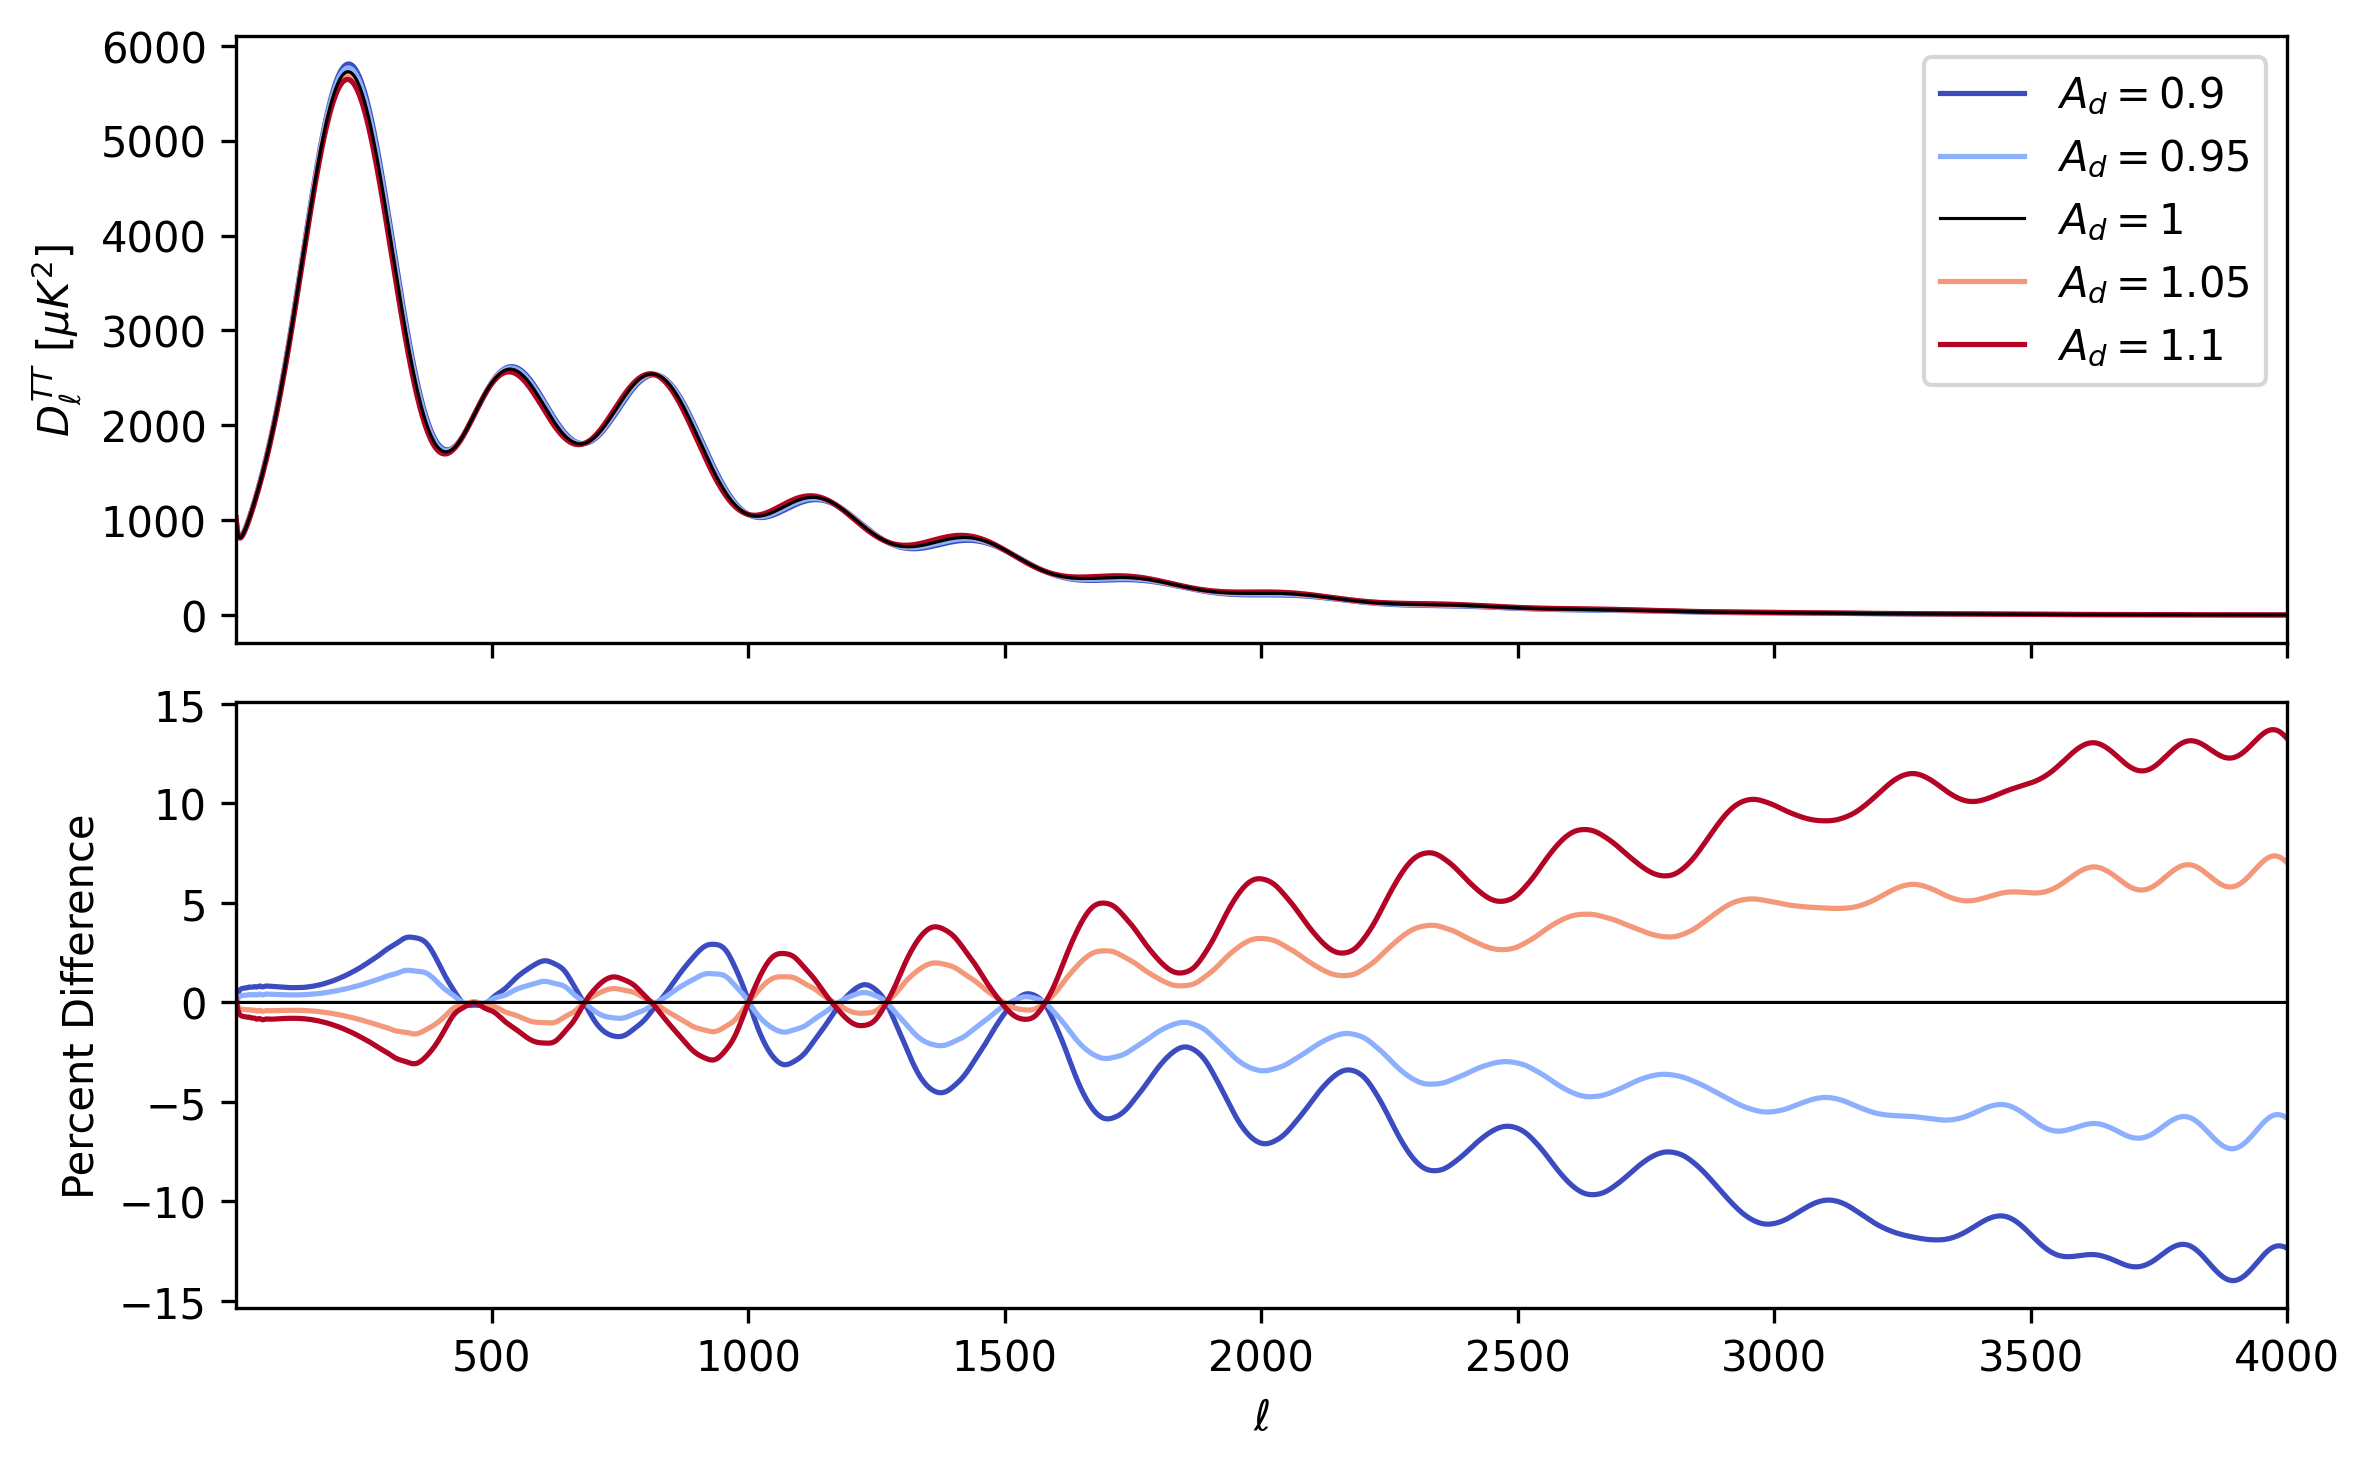

In [74]:
cmap = plt.cm.coolwarm
norm = TwoSlopeNorm(vmin=min(thomson_rescaling_values),vcenter=1.0,vmax=max(thomson_rescaling_values))
quantity_to_plot = "TT"
quantity_to_plot_indexes = {
    "TT": 1, "EE": 2, "TE": 3, "BB": 4
} 
T_cmb = 2.7255
factor = T_cmb**2 * 1e12

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5), dpi=300, sharex=True)

# A_d = 1.0
tr = 1.0
tr_name = f"{tr:g}".replace(".", "p")
filename = f"../output/Ad{tr_name}_rescale_00_cl_lensed.dat"
data = np.loadtxt(filename)
ell_baseline = data[:, 0]
TT_baseline = data[:, quantity_to_plot_indexes[quantity_to_plot]] * factor
#filename = f"../output/Ad{tr_name}_rescale_00_cl.dat"
#data = np.loadtxt(filename)
#ell_baseline_unlensed = data[:, 0]
#TT_baseline_unlensed = data[:, quantity_to_plot_indexes[quantity_to_plot]] * factor

# non-unity A_d
for tr in thomson_rescaling_values:
    tr_name = f"{tr:g}".replace(".", "p")
    filename = f"../output/Ad{tr_name}_rescale_00_cl_lensed.dat"
    data = np.loadtxt(filename)
    ell = data[:, 0]
    TT = data[:, quantity_to_plot_indexes[quantity_to_plot]] * factor

    #filename = f"../output/Ad{tr_name}_rescale_00_cl.dat"
    #data = np.loadtxt(filename)
    #ell_unlensed = data[:, 0]
    #TT_unlensed = data[:, quantity_to_plot_indexes[quantity_to_plot]] * factor

    if np.isclose(tr, 1.0):
        color = "black"
        linewidth = 0.75
        zorder = 10
    else:
        color = cmap(norm(tr))
        linewidth = 1.25
        zorder = 1
        
    ax1.plot(ell,TT,
             color=color,linewidth=linewidth,label=fr"$A_d={tr:g}$",zorder=zorder)
    #ax1.plot(ell_unlensed,TT_unlensed,
    #         color=color,linewidth=linewidth,zorder=zorder,ls='--')
    ax2.plot(ell,100*(TT-TT_baseline)/TT_baseline,
             color=color,linewidth=linewidth,label=fr"$A_d={tr:g}$",zorder=zorder)
    #ax2.plot(ell_unlensed,100*(TT_unlensed-TT_baseline_unlensed)/TT_baseline_unlensed,
    #         color=color,linewidth=linewidth,zorder=zorder,ls='--')

ax1.set_ylabel(
    rf"$D_\ell^{{{quantity_to_plot}}}\ [\mu K^2]$"
)
ax2.set_ylabel(
    r"Percent Difference"
)

ax2.set_xlabel(r"$\ell$")
ax2.set_xlim(2, 4000)
#ax2.set_ylim(-100,100)

ax1.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [11]:
phenomenological_damping_tail_values = [0, 1000, 2000, 3000, 4000]

for tr in phenomenological_damping_tail_values:
    tr_name = f"{tr:g}".replace(".", "p") # e.g. 0.95 -> "0p95"

    ini_path = Path(f"elld{tr_name}_rescale.ini")
    params = default_params.copy()
    params["root"] = f"../output/elld{tr_name}_rescale_"
    params["phenomenological_damping_tail"] = tr

    with open(ini_path, "w") as f:
        for key, value in params.items():
            f.write(f"{key} = {value}\n")
    print(f"Wrote {ini_path}")

    result = subprocess.run(
        ["../class", str(ini_path)],
        capture_output=True,
        text=True
    )
    print(result.stdout)
    if result.returncode != 0:
        print("CLASS ERROR:")
        print(result.stderr)
    else:
        print(f"Finished phenomenological_damping_tail = {tr}")

Wrote elld0_rescale.ini
Reading input parameters
 -> matched budget equations by adjusting Omega_Lambda = 0.690026
Running CLASS version v3.4.0
Computing background
 -> age = 13.770598 Gyr
 -> conformal age = 14151.897989 Mpc
 -> N_eff = 3.044 (summed over all species that are non-relativistic at early times) 
 -> radiation/matter equality at z = 3405.751108
    corresponding to conformal time = 112.722902 Mpc
Computing thermodynamics using HyRec 2020
 -> with primordial helium mass fraction Y_He = 0.2453
 -> recombination (maximum of visibility function) at z = 1088.772283
    corresponding to conformal time = 280.650572 Mpc
    with comoving sound horizon = 144.510391 Mpc
    angular diameter distance = 12.728574 Mpc
    sound horizon angle 100*theta_s = 1.041798
    Thomson optical depth crosses one at z_* = 1085.125754
    giving an angle 100*theta_* = 1.044146
 -> baryon drag stops at z = 1059.919234
    corresponding to conformal time = 286.316633 Mpc
    with comoving sound hori

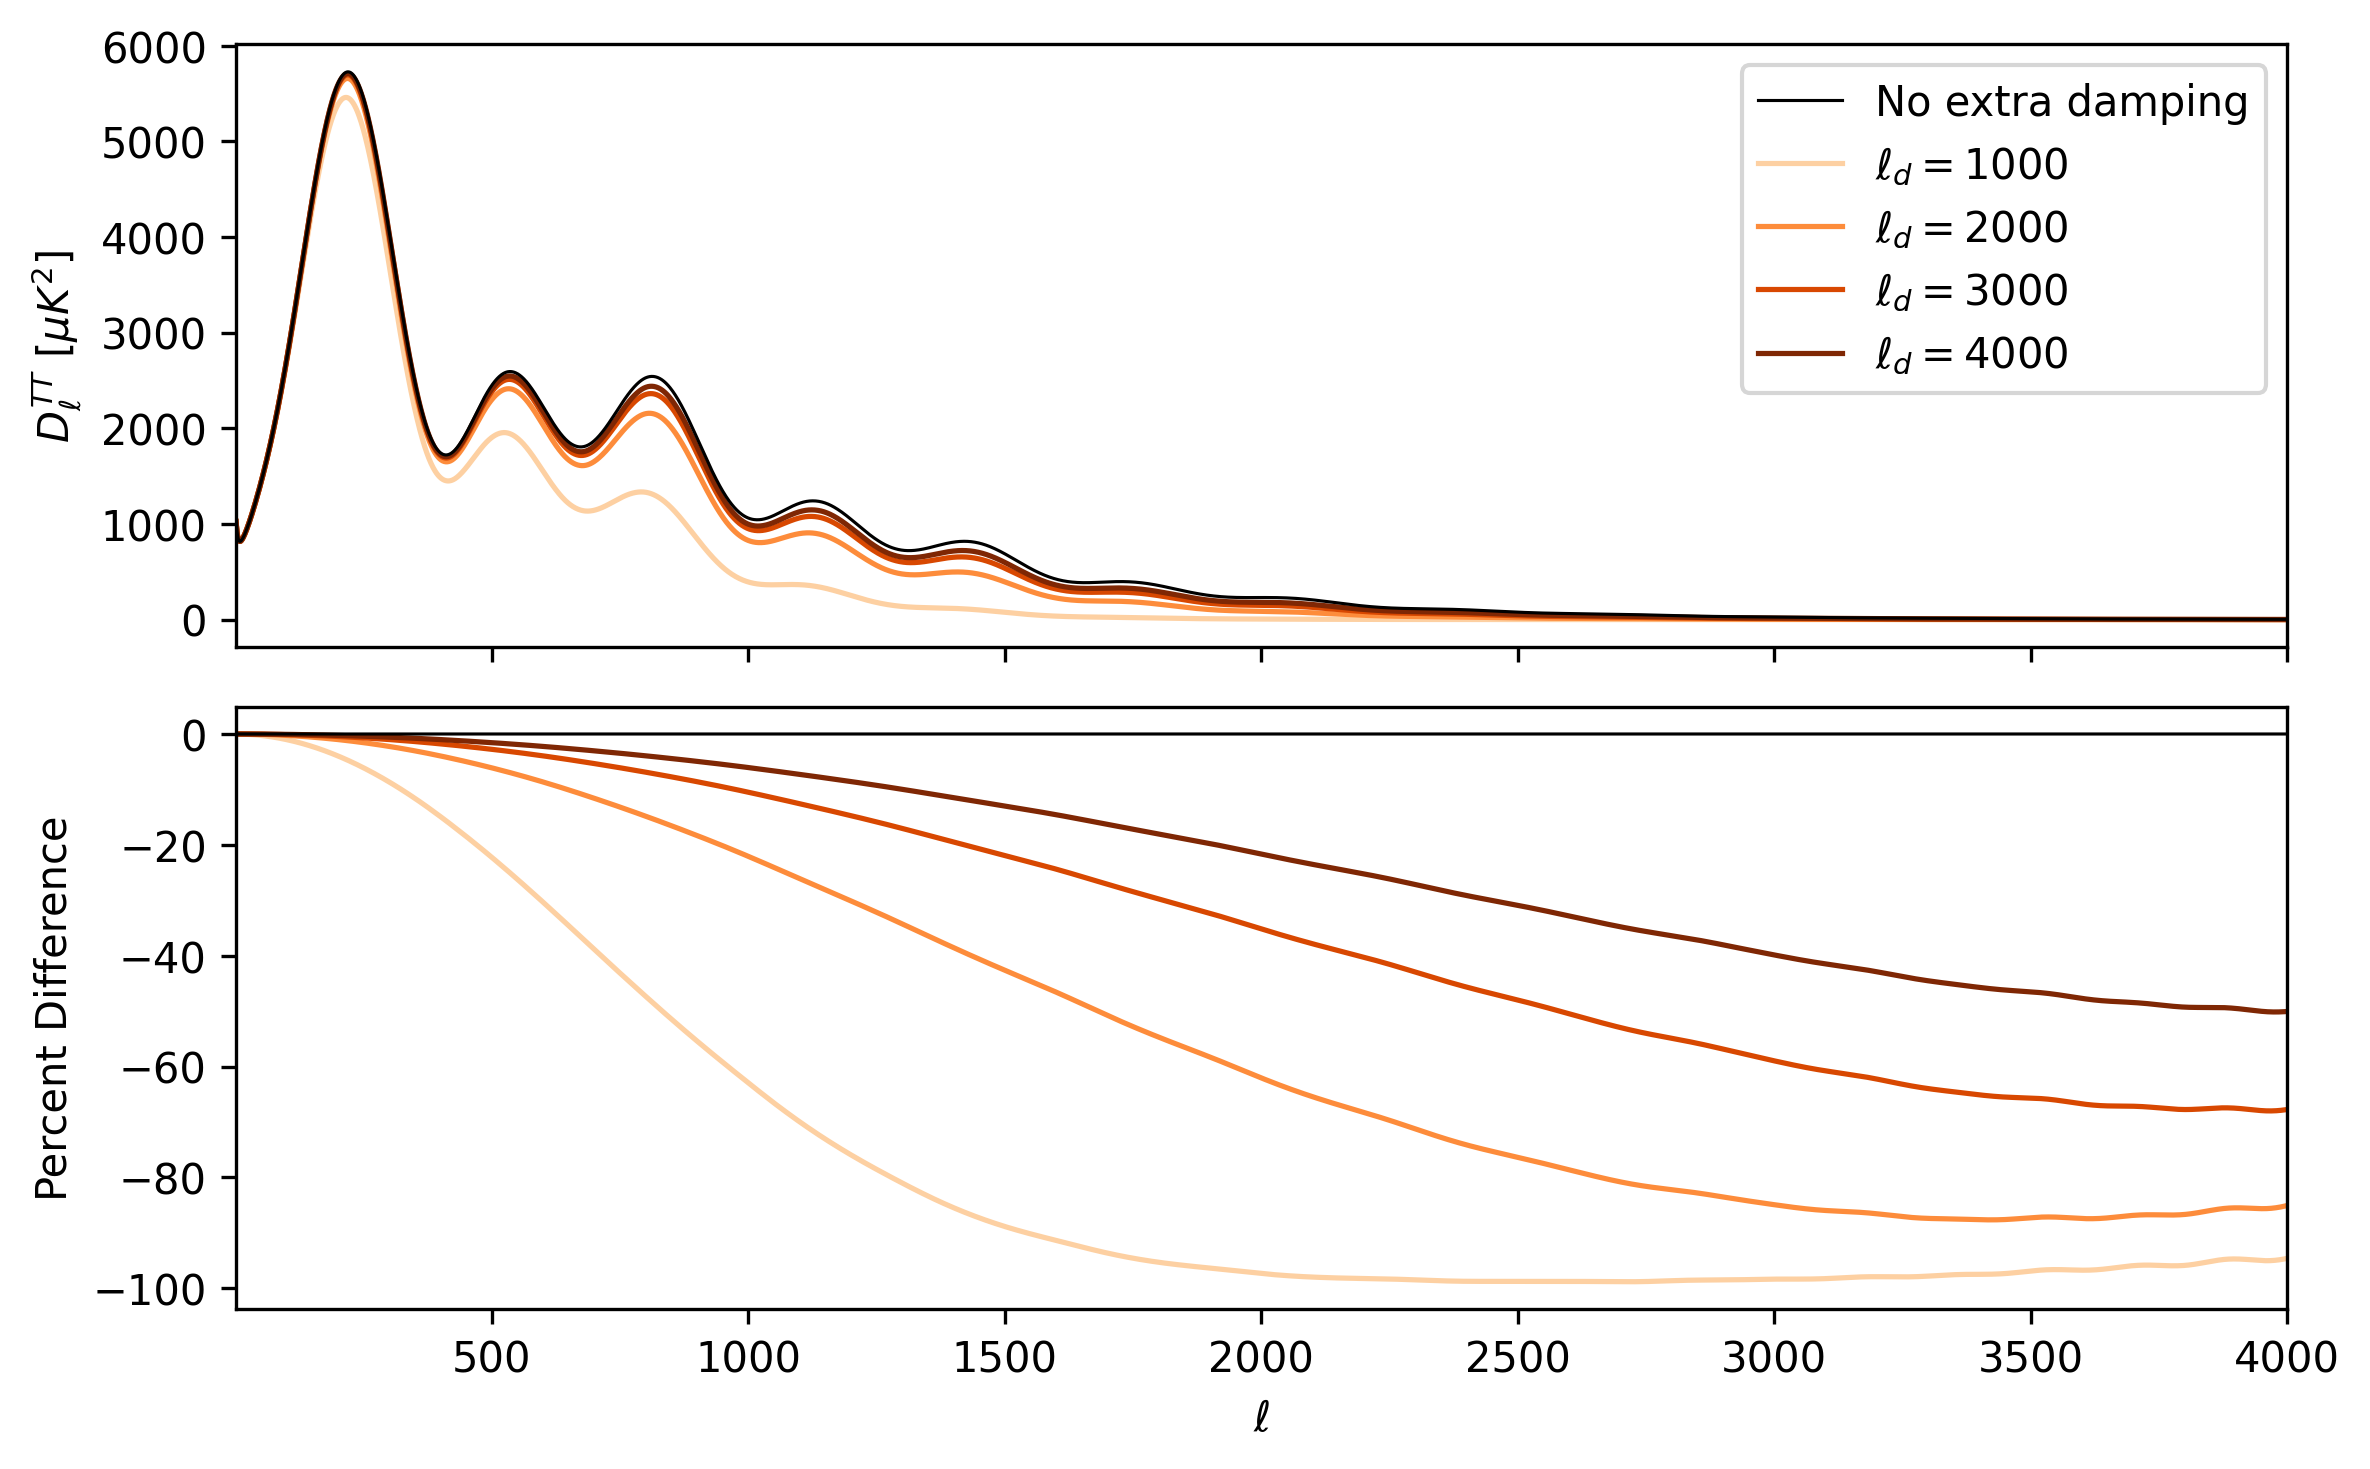

In [14]:
cmap = plt.cm.Oranges
norm = plt.Normalize(vmin=min(phenomenological_damping_tail_values),vmax=max(phenomenological_damping_tail_values))
quantity_to_plot = "TT"
quantity_to_plot_indexes = {
    "TT": 1, "EE": 2, "TE": 3, "BB": 4
} 
T_cmb = 2.7255
factor = T_cmb**2 * 1e12

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5), dpi=300, sharex=True)

# A_d = 1.0
tr = 0
tr_name = f"{tr:g}".replace(".", "p")
filename = f"../output/elld{tr_name}_rescale_00_cl_lensed.dat"
data = np.loadtxt(filename)
ell_baseline = data[:, 0]
TT_baseline = data[:, quantity_to_plot_indexes[quantity_to_plot]] * factor
#filename = f"../output/elld{tr_name}_rescale_00_cl.dat"
#data = np.loadtxt(filename)
#ell_baseline_unlensed = data[:, 0]
#TT_baseline_unlensed = data[:, quantity_to_plot_indexes[quantity_to_plot]] * factor

# non-unity A_d
for tr in phenomenological_damping_tail_values:
    tr_name = f"{tr:g}".replace(".", "p")
    filename = f"../output/elld{tr_name}_rescale_00_cl_lensed.dat"
    data = np.loadtxt(filename)
    ell = data[:, 0]
    TT = data[:, quantity_to_plot_indexes[quantity_to_plot]] * factor

    #filename = f"../output/elld{tr_name}_rescale_00_cl.dat"
    #data = np.loadtxt(filename)
    #ell_unlensed = data[:, 0]
    #TT_unlensed = data[:, quantity_to_plot_indexes[quantity_to_plot]] * factor

    if np.isclose(tr, 0):
        color = "black"
        linewidth = 0.75
        zorder = 10

        ax1.plot(ell,TT,
                 color=color,linewidth=linewidth,label=fr"No extra damping",zorder=zorder)
        #ax1.plot(ell_unlensed,TT_unlensed,
        #         color=color,linewidth=linewidth,zorder=zorder,ls='--')
        ax2.plot(ell,100*(TT-TT_baseline)/TT_baseline,
                 color=color,linewidth=linewidth,label=fr"No extra damping",zorder=zorder)
        #ax2.plot(ell_unlensed,100*(TT_unlensed-TT_baseline_unlensed)/TT_baseline_unlensed,
        #         color=color,linewidth=linewidth,zorder=zorder,ls='--')
    else:
        color = cmap(norm(tr))
        linewidth = 1.25
        zorder = 1
        
        ax1.plot(ell,TT,
                 color=color,linewidth=linewidth,label=fr"$\ell_d={tr:g}$",zorder=zorder)
        #ax1.plot(ell_unlensed,TT_unlensed,
        #         color=color,linewidth=linewidth,zorder=zorder,ls='--')
        ax2.plot(ell,100*(TT-TT_baseline)/TT_baseline,
                 color=color,linewidth=linewidth,label=fr"$\ell_d={tr:g}$",zorder=zorder)
        #ax2.plot(ell_unlensed,100*(TT_unlensed-TT_baseline_unlensed)/TT_baseline_unlensed,
        #         color=color,linewidth=linewidth,zorder=zorder,ls='--')

ax1.set_ylabel(
    rf"$D_\ell^{{{quantity_to_plot}}}\ [\mu K^2]$"
)
ax2.set_ylabel(
    r"Percent Difference"
)

ax2.set_xlabel(r"$\ell$")
ax2.set_xlim(2, 4000)
#ax2.set_ylim(-100,100)

ax1.legend(loc='upper right')
plt.tight_layout()
plt.show()